In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load data safely
data = pd.read_csv('Data/online_retail_cleaned.csv')
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], errors='coerce')

# Drop any problematic rows
data = data.dropna(subset=['InvoiceDate','TotalPrice'])


## Part 5: EDA

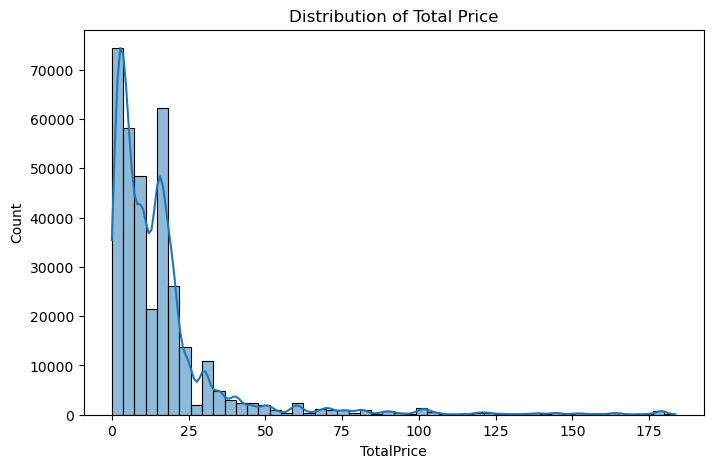

In [4]:
# Distribution (remove extreme outliers)
filtered = data[data['TotalPrice'] < data['TotalPrice'].quantile(0.99)]
plt.figure(figsize=(8,5))
sns.histplot(filtered['TotalPrice'], bins=50, kde=True)
plt.title('Distribution of Total Price')
plt.show()

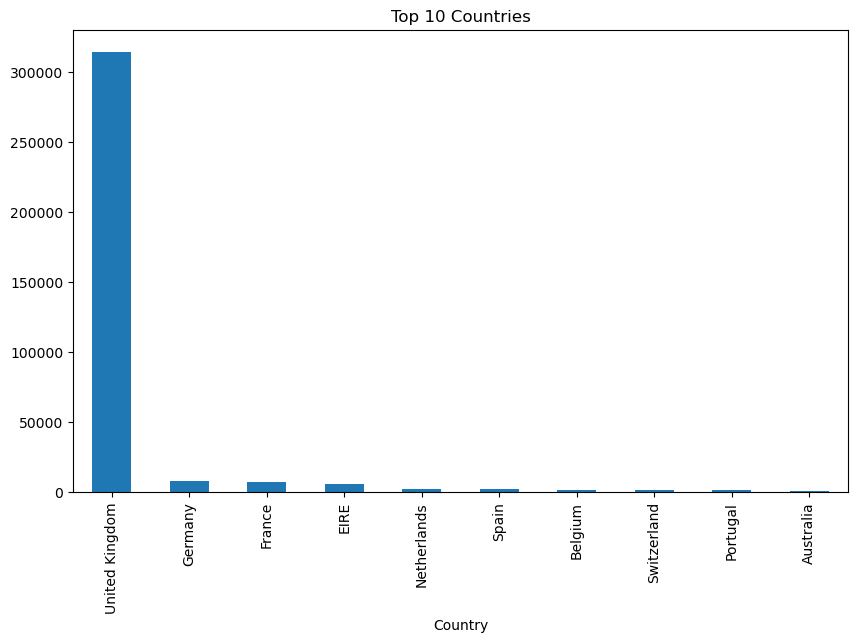

In [5]:
# Top Countries
plt.figure(figsize=(10,6))
data['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries')
plt.show()


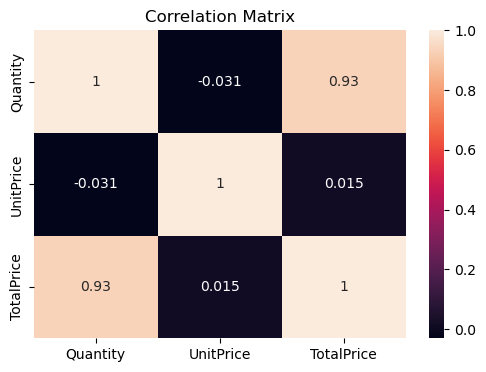

In [6]:
# Correlation
plt.figure(figsize=(6,4))
corr = data[['Quantity','UnitPrice','TotalPrice']].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()


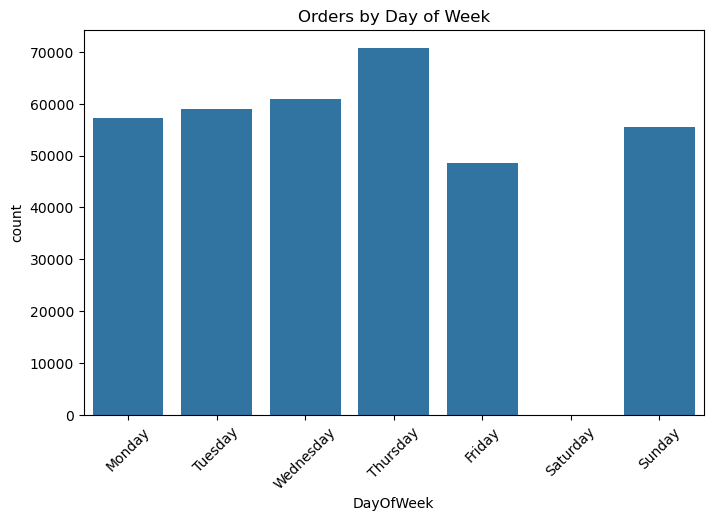

In [7]:
# Orders by Day
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(8,5))
sns.countplot(x='DayOfWeek', data=data, order=order_days)
plt.xticks(rotation=45)
plt.title('Orders by Day of Week')
plt.show()


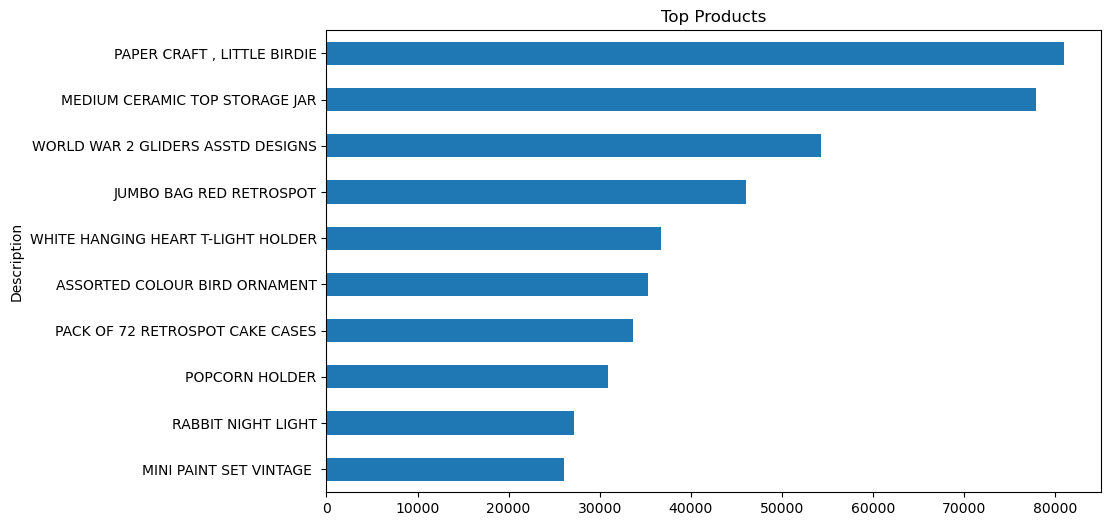

In [8]:
# Top Products
top_products = data.groupby('Description')['Quantity'].sum().nlargest(10)
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top Products')
plt.show()


## Part 6: Time Series

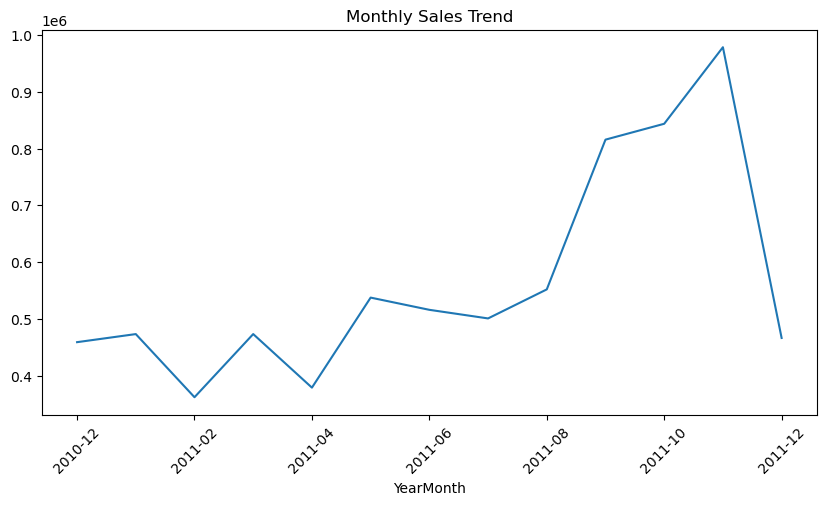

In [9]:
# Monthly Sales
if 'YearMonth' in data.columns:
    monthly_sales = data.groupby('YearMonth')['TotalPrice'].sum()
    monthly_sales.index = monthly_sales.index.astype(str)
else:
    monthly_sales = data.groupby(data['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
    monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.show()


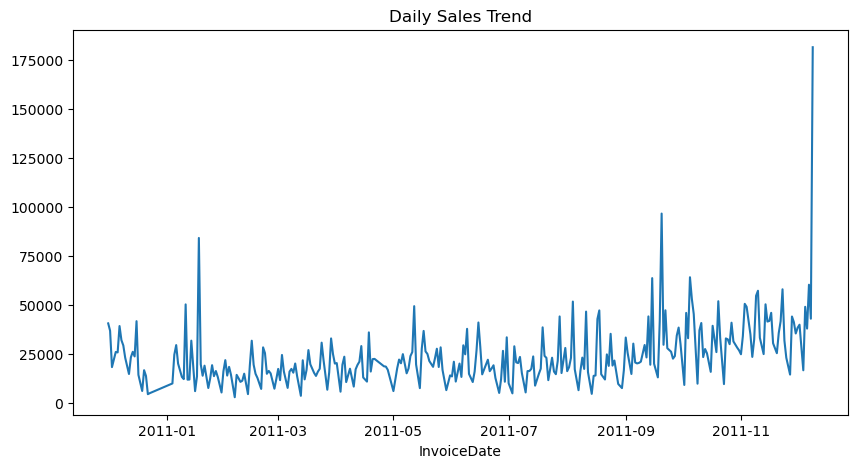

In [10]:
# Daily Sales
daily_sales = data.groupby(data['InvoiceDate'].dt.date)['TotalPrice'].sum()
plt.figure(figsize=(10,5))
daily_sales.plot()
plt.title('Daily Sales Trend')
plt.show()


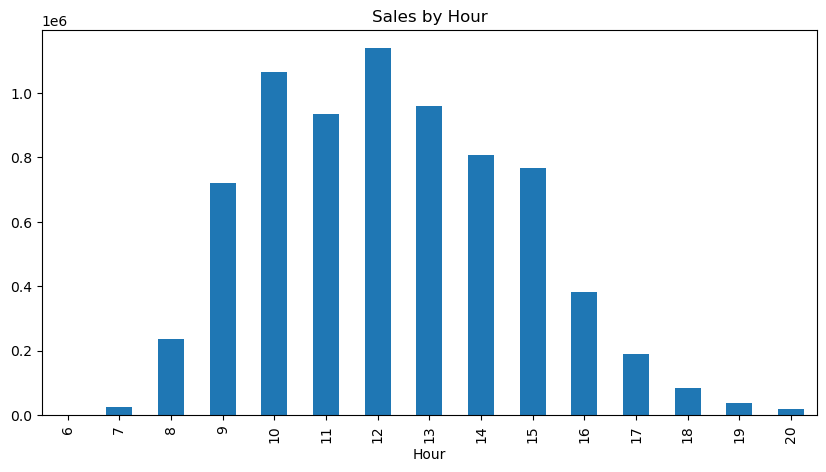

In [11]:
# Hourly Sales
if 'Hour' in data.columns:
    hourly_sales = data.groupby('Hour')['TotalPrice'].sum()
else:
    data['Hour'] = data['InvoiceDate'].dt.hour
    hourly_sales = data.groupby('Hour')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
hourly_sales.sort_index().plot(kind='bar')
plt.title('Sales by Hour')
plt.show()


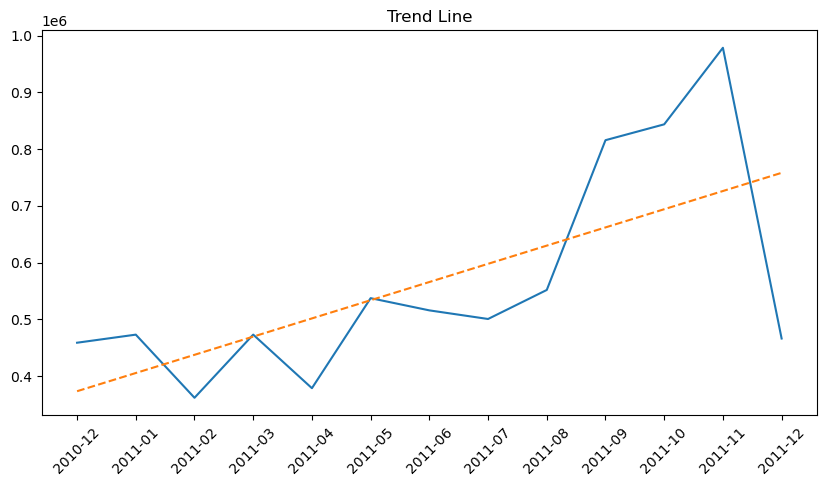

In [12]:
# Trend Line
x = np.arange(len(monthly_sales))
y = monthly_sales.values
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, y)
plt.plot(monthly_sales.index, p(x), '--')
plt.xticks(rotation=45)
plt.title('Trend Line')
plt.show()
